# Logical H and S Gates — Fold-Transversal

Fold-transversal gates exploit the geometric symmetry of the unrotated surface code.
A **fold** maps each qubit to its mirror image across the patch diagonal, composing
physical SWAP gates with a transversal single-qubit gate to implement a logical Clifford.

- **H gate**: fold along the main diagonal, apply transversal H to all data qubits.
- **S gate**: fold along the anti-diagonal, apply transversal S.  
  Verified via the S-roundtrip circuit: prepare |+⟩, apply S (noisy), apply S† (noiseless), measure X.

Both circuits: init → SE rounds → gate → SE rounds → readout.

In [1]:
import sys
from pathlib import Path
import io, contextlib

ROOT = Path("../..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from lightstim.protocols.fold_transversal import (
    build_gate_verification_circuit,
    build_s_roundtrip_circuit,
)
from lightstim.noise.config import NoiseConfig
from lightstim.simulation.decoder_backend import SimulationPipeline, DecoderConfig

In [2]:
d = 3
p = 1e-3
rounds = 1
noise_params = NoiseConfig(p_idle=p, p_1q=p, p_2q=p, p_meas=p, p_reset=p)

## 1. H Gate Circuit

Two sub-experiments verifying the CNOT action on logical bases:
- `H_ZtoX`: prepare |0⟩_L (Z-basis), apply H, measure X-basis → expect +1.
- `H_XtoZ`: prepare |+⟩_L (X-basis), apply H, measure Z-basis → expect +1.

In [3]:
with contextlib.redirect_stdout(io.StringIO()):
    circuit_H_ZtoX = build_gate_verification_circuit(
        d, ["fold_transversal_hadamard"], init_basis="Z", measure_basis="X",
        rounds=rounds, unencode=False, noise_params=noise_params,
    )
    circuit_H_XtoZ = build_gate_verification_circuit(
        d, ["fold_transversal_hadamard"], init_basis="X", measure_basis="Z",
        rounds=rounds, unencode=False, noise_params=noise_params,
    )

print(f"H (Z→X): {circuit_H_ZtoX.num_qubits} qubits, {circuit_H_ZtoX.num_detectors} detectors")
print(f"H (X→Z): {circuit_H_XtoZ.num_qubits} qubits, {circuit_H_XtoZ.num_detectors} detectors")

H (Z→X): 25 qubits, 24 detectors
H (X→Z): 25 qubits, 24 detectors


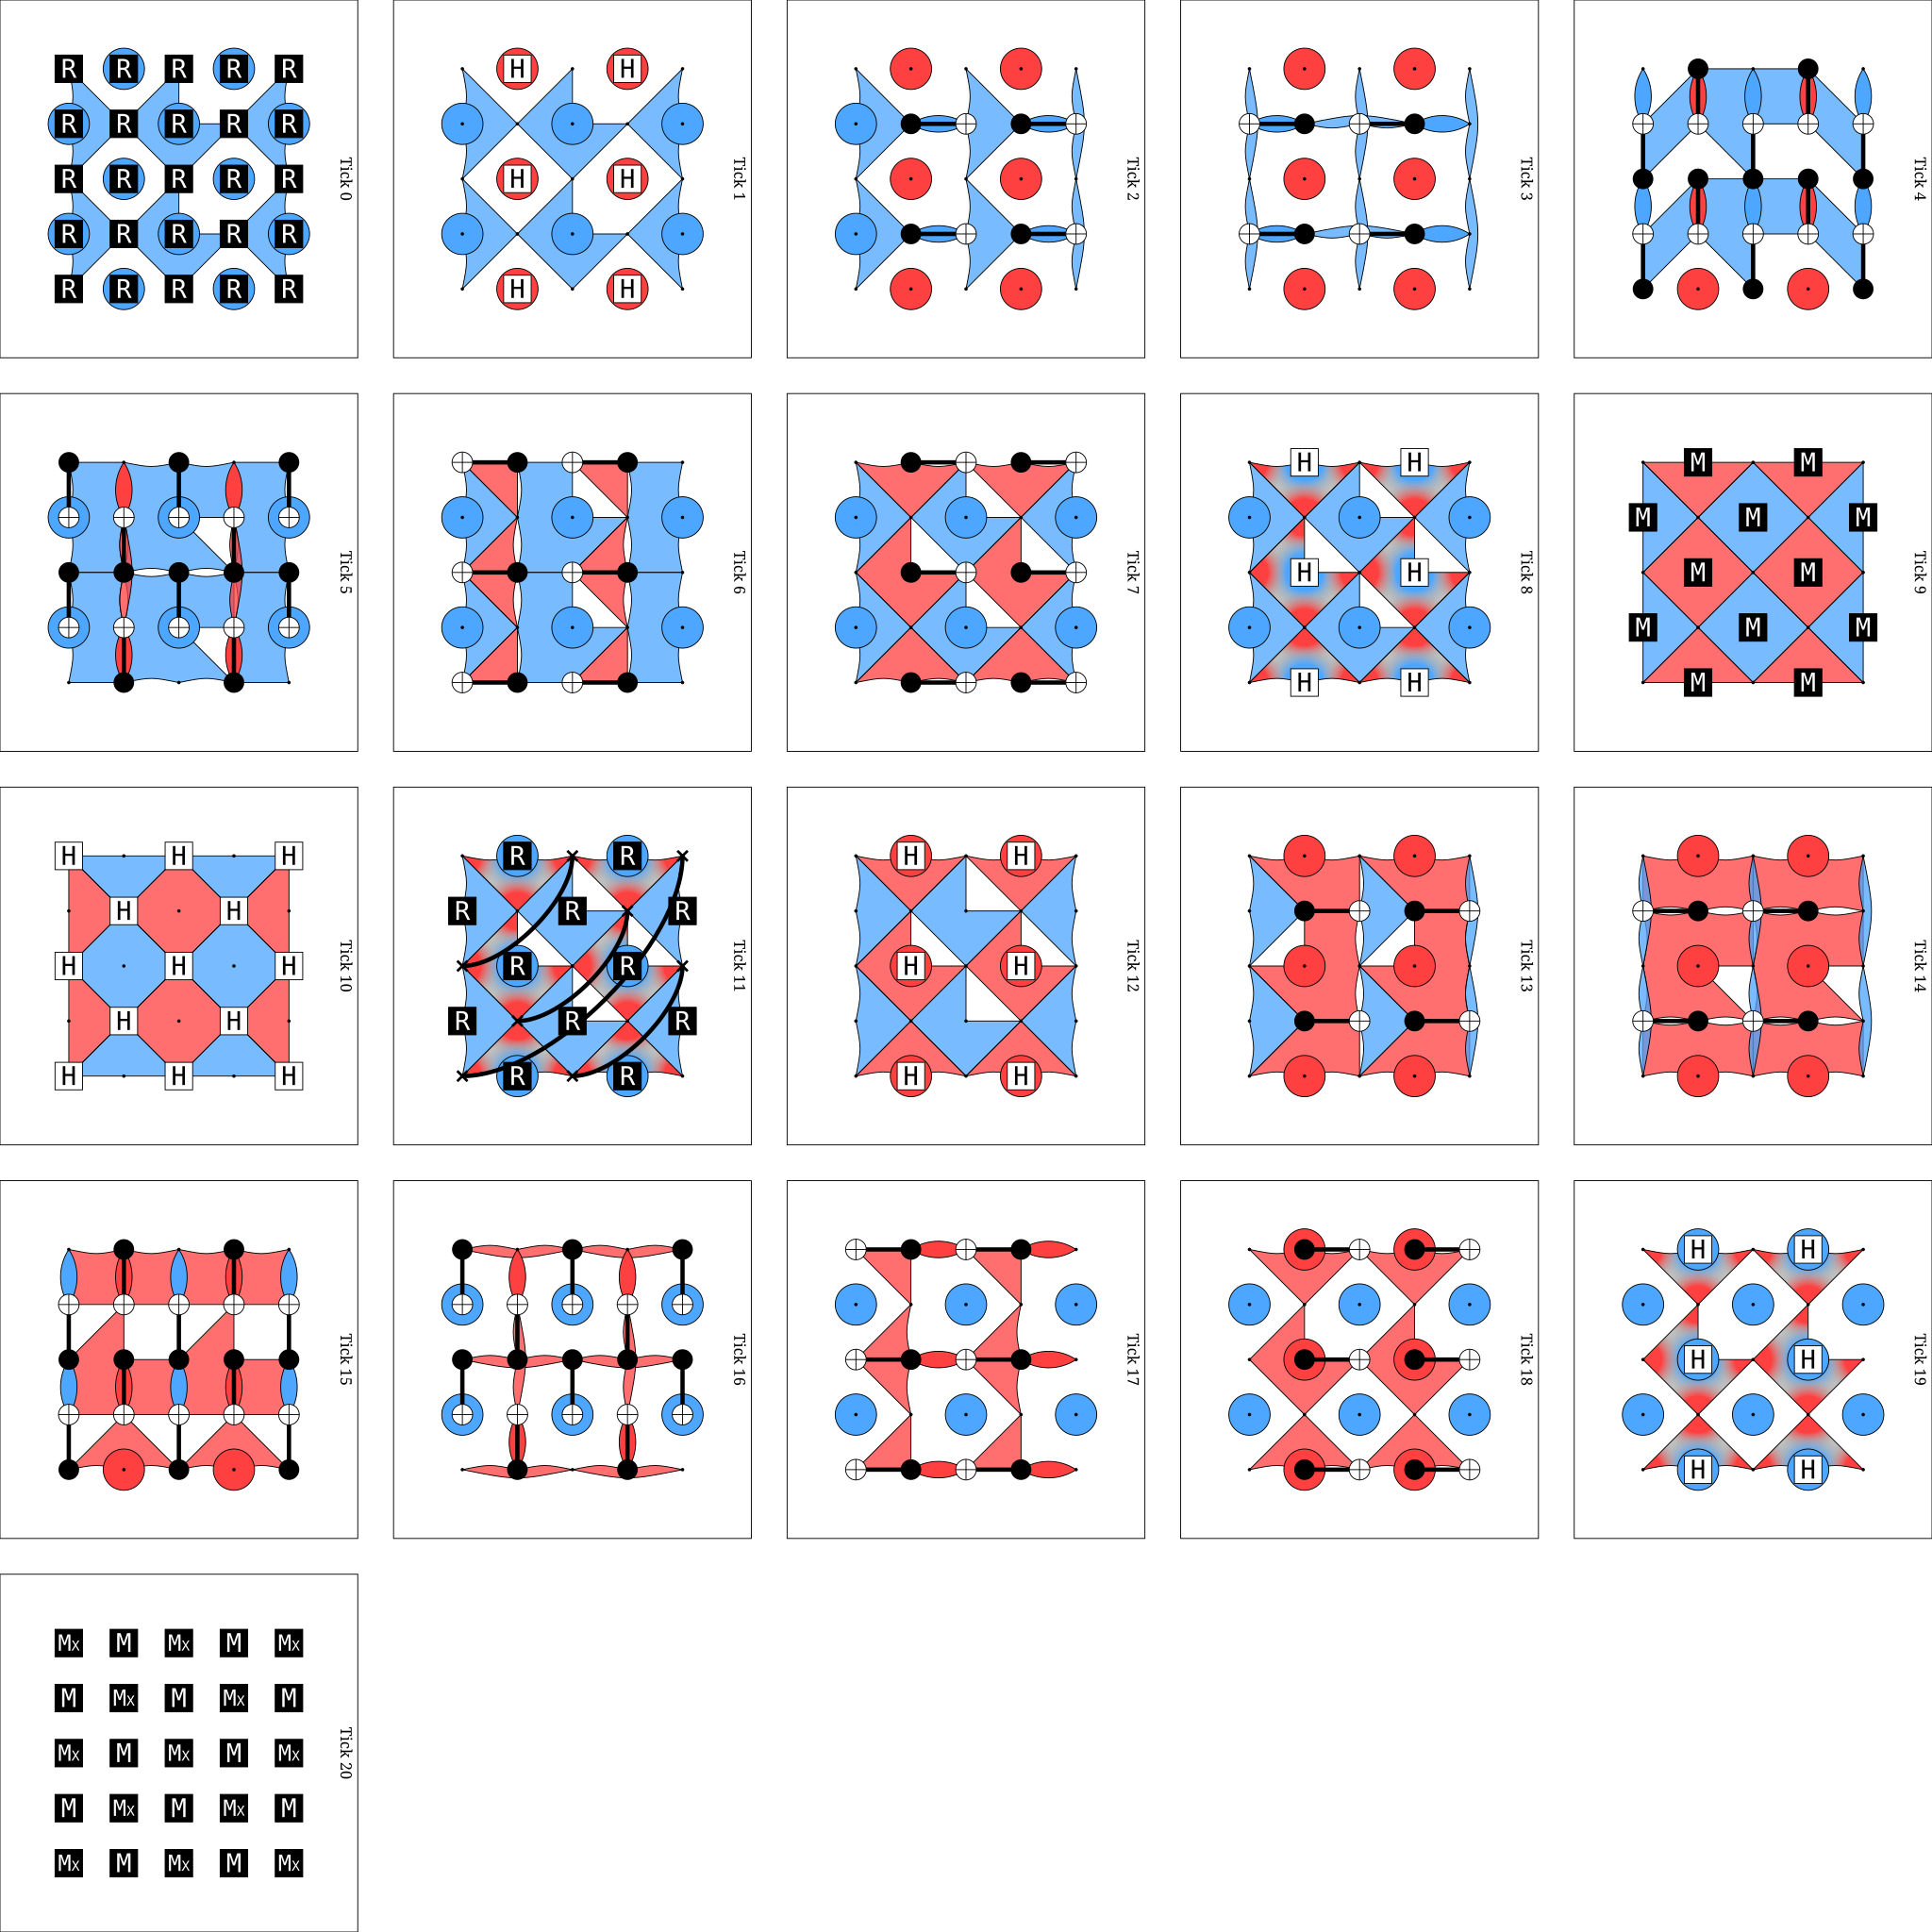

In [4]:
circuit_H_ZtoX.without_noise().diagram("detslice-with-ops-svg")

## 2. S Gate Circuit

S-roundtrip: prepare |+⟩_L, apply S (noisy), apply S† (noiseless), measure X-basis.  
Errors propagate from the noisy S; the noiseless S† unwinds the gate without adding errors.

In [5]:
with contextlib.redirect_stdout(io.StringIO()):
    circuit_S = build_s_roundtrip_circuit(d, rounds=rounds, noise_params=noise_params)

print(f"S roundtrip: {circuit_S.num_qubits} qubits, {circuit_S.num_detectors} detectors")

S roundtrip: 25 qubits, 36 detectors


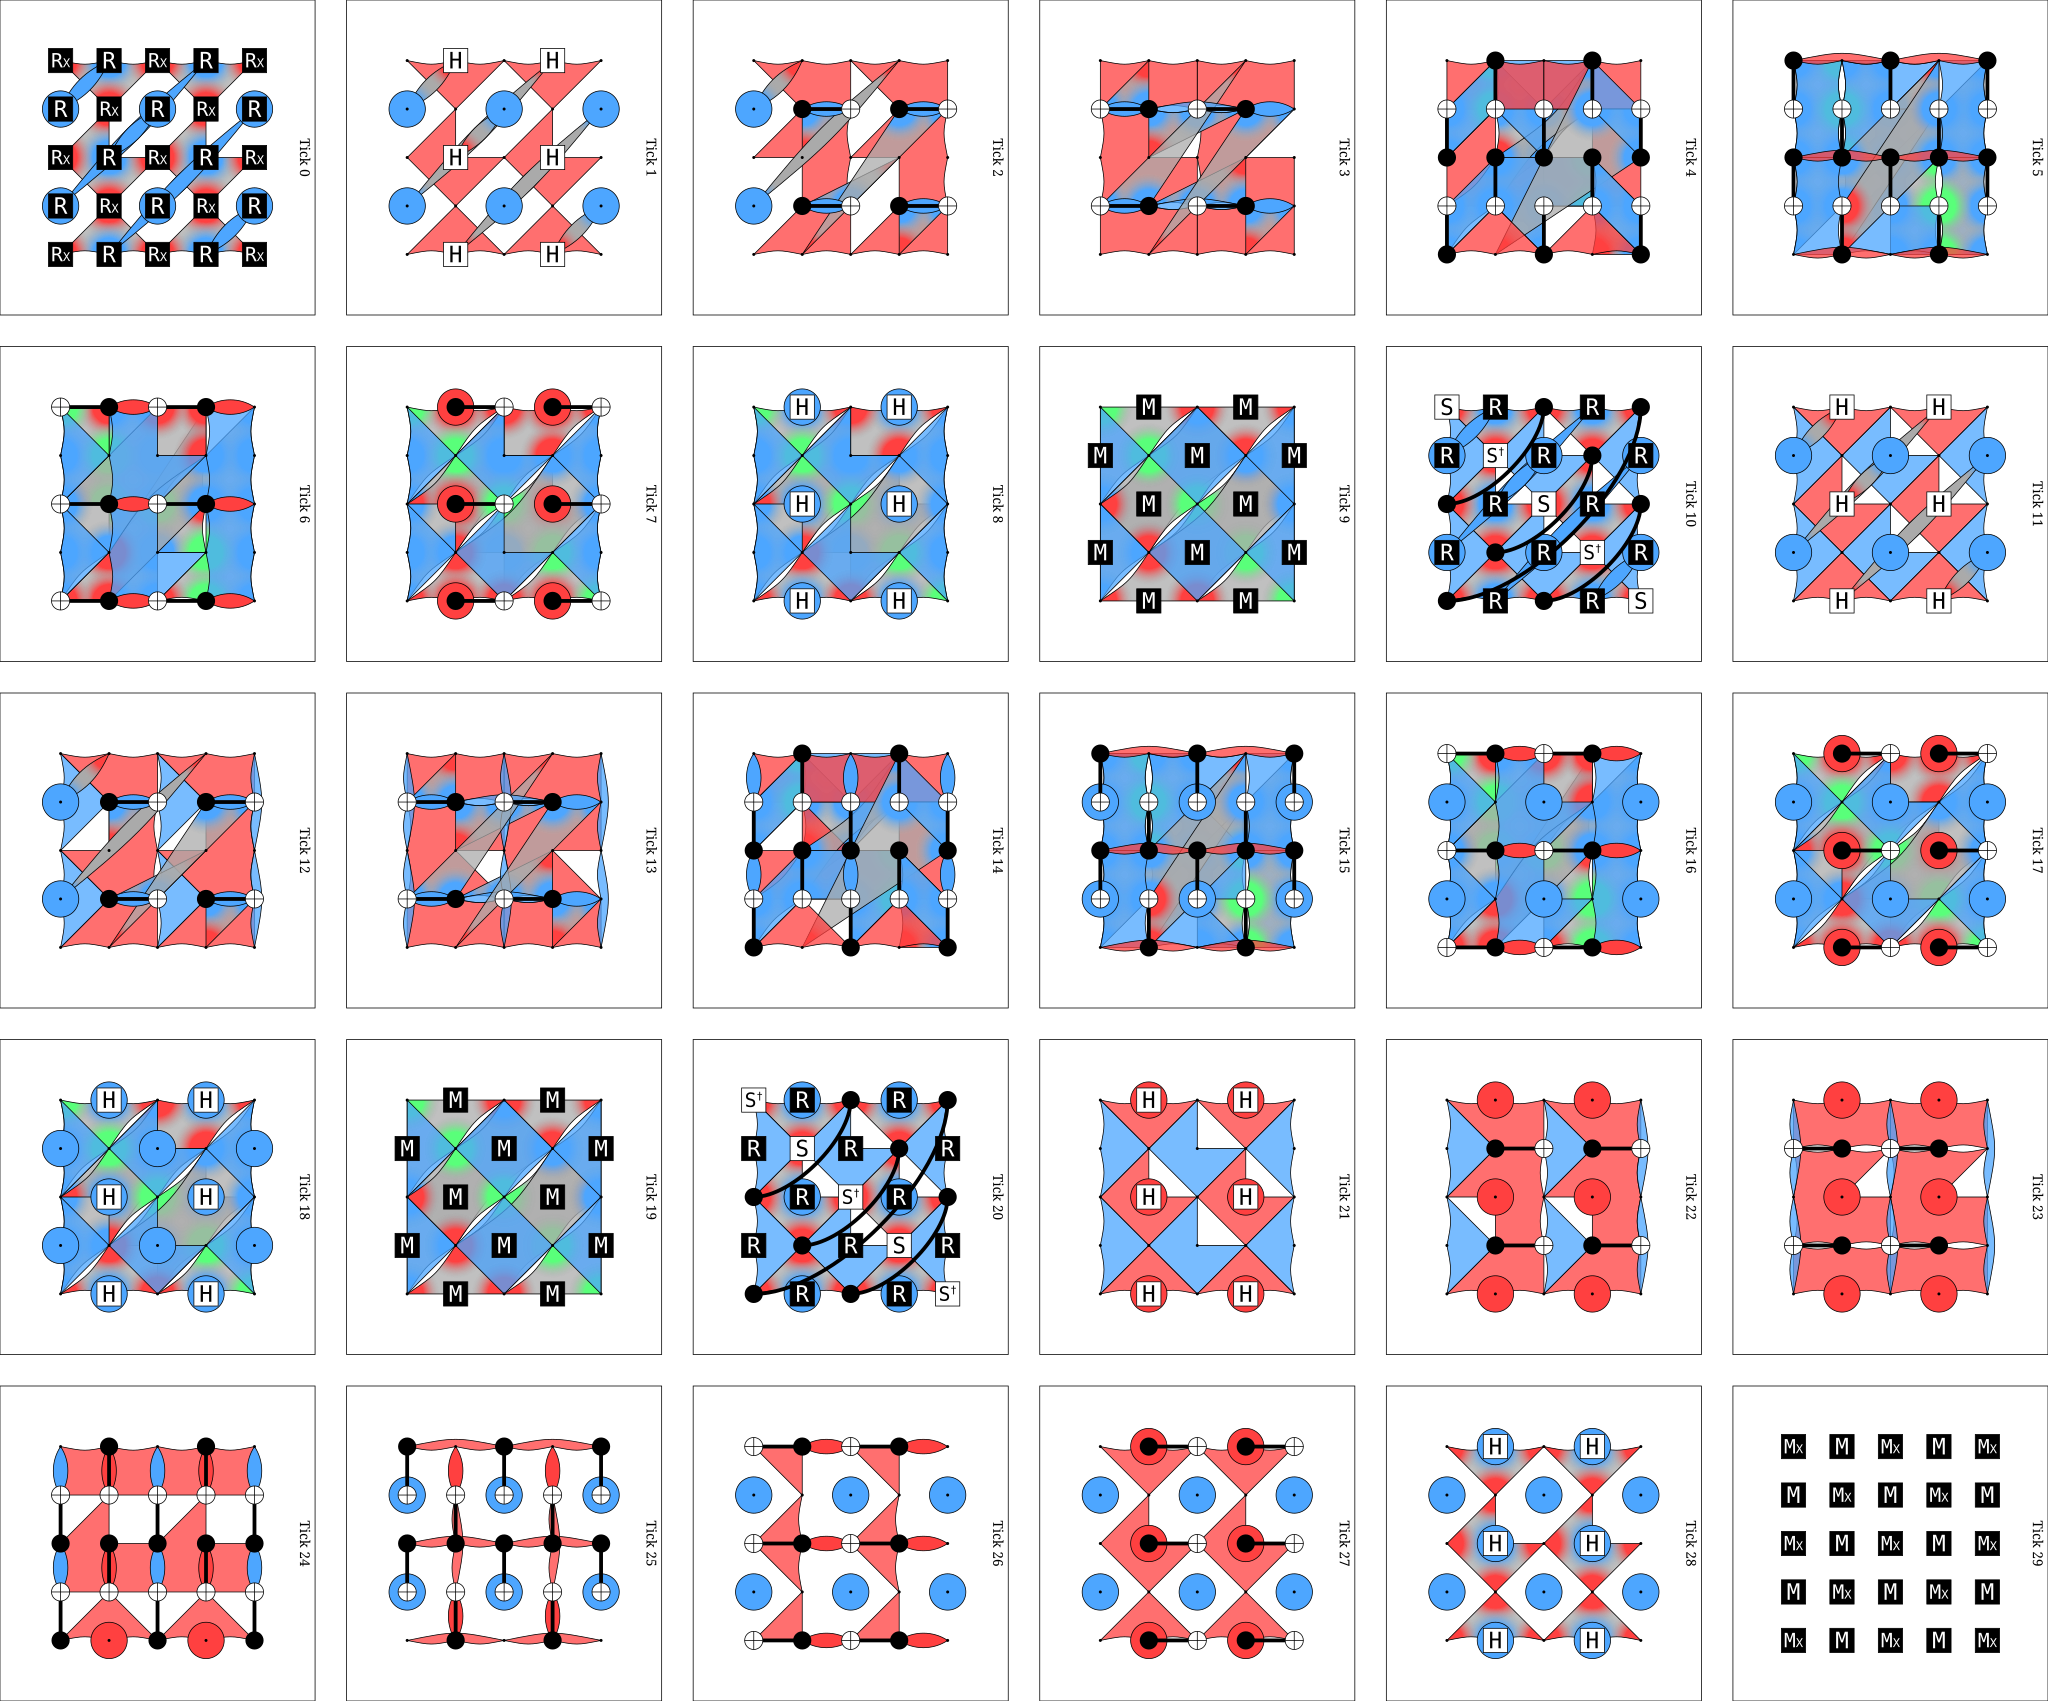

In [6]:
circuit_S.without_noise().diagram("detslice-with-ops-svg")

## 3. Noiseless Sanity Check

In [7]:
for label, circ in [
    ("H Z→X", circuit_H_ZtoX),
    ("H X→Z", circuit_H_XtoZ),
    ("S roundtrip", circuit_S),
]:
    sampler = circ.without_noise().compile_detector_sampler()
    det, obs = sampler.sample(shots=200, separate_observables=True)
    print(f"{label}: clean={not det.any() and not obs.any()}")

H Z→X: clean=True
H X→Z: clean=True
S roundtrip: clean=True


## 4. Simulation with BP+OSD (d=3, p=1e-3, 100k shots)

BP+OSD handles the non-CSS correlations introduced by H and S gates
(PyMatching can fail on these circuits).

In [8]:
pipeline = SimulationPipeline(
    decoder_config=DecoderConfig("bposd", backend="cpu"),
    max_shots=100_000,
    max_errors=50,
    num_workers=4,
    print_progress=False,
)

for label, circ in [
    ("H Z→X", circuit_H_ZtoX),
    ("H X→Z", circuit_H_XtoZ),
    ("S roundtrip", circuit_S),
]:
    stats = pipeline.run(circ)
    print(f"{label}: LER={stats.logical_error_rate:.2e}  ({stats.errors} errors / {stats.shots:,} shots)")

H Z→X: LER=8.00e-04  (80 errors / 100,000 shots)
H X→Z: LER=7.30e-04  (73 errors / 100,000 shots)
S roundtrip: LER=1.29e-03  (103 errors / 80,000 shots)


## 5. LER vs Physical Error Rate — Hadamard

Sweep `p ∈ {1e-3, 2e-3, 3e-3, 5e-3, 7e-3, 1e-2}` and plot the **mean logical error
rate over the two H sub-experiments** (Z→X, X→Z), one curve per code distance
(`d = 3, 5, 7`). Below threshold the larger code suppresses errors. The transversal H
is graphlike, so MWPM (PyMatching) decodes it exactly. The figure is saved to
`logical_H_unrotated_LER_vs_p.png`.

  d         p   mean LER (over H Z->X, X->Z)
------------------------------------------------


  3     1e-03   9.403e-04


  3     2e-03   3.383e-03


  3     3e-03   7.425e-03


  3     5e-03   1.917e-02


...

  7     2e-03   1.500e-05


  7     3e-03   2.225e-04


  7     5e-03   1.877e-03


  7     7e-03   7.494e-03


  7     1e-02   3.043e-02


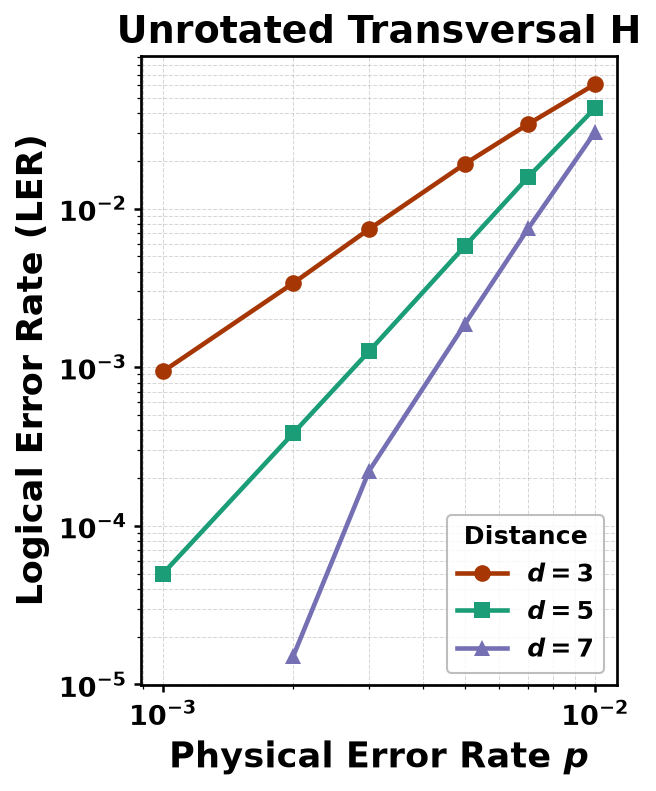

In [3]:
# ── LER vs Physical Error Rate — Hadamard ─────────────────────────────────────
import logging
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from lightstim.plot.styles import apply_paper_style, bold_ticks, PALETTE_DISTANCE
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)  # silence bold-font warnings

P_SWEEP   = [1e-3, 2e-3, 3e-3, 5e-3, 7e-3, 1e-2]
DISTANCES = [3, 5, 7]
MARKERS   = {3: "o", 5: "s", 7: "^"}

sweep_pipeline = SimulationPipeline(
    decoder_config=DecoderConfig("pymatching", backend="cpu"),
    max_shots=200_000,
    max_errors=60,
    num_workers=8,
    print_progress=False,
)

def ler_H(dd, noise):
    lers = []
    for ib, mb in [("Z", "X"), ("X", "Z")]:
        with contextlib.redirect_stdout(io.StringIO()):
            c = build_gate_verification_circuit(
                dd, ["fold_transversal_hadamard"], init_basis=ib, measure_basis=mb,
                rounds=rounds, unencode=False, noise_params=noise)
        lers.append(sweep_pipeline.run(c).logical_error_rate)
    return float(np.mean(lers))

ler_curves = {dd: [] for dd in DISTANCES}
print(f"{'d':>3} {'p':>9}   mean LER (over H Z->X, X->Z)")
print("-" * 48)
for dd in DISTANCES:
    for pp in P_SWEEP:
        noise = NoiseConfig(p_idle=pp, p_1q=pp, p_2q=pp, p_meas=pp, p_reset=pp)
        v = ler_H(dd, noise)
        ler_curves[dd].append(v)
        print(f"{dd:>3} {pp:>9.0e}   {v:.3e}")

apply_paper_style()
fig, ax = plt.subplots(figsize=(4.5, 5.5))
proxies = []
for dd in DISTANCES:
    color  = PALETTE_DISTANCE.get(dd, "gray")
    marker = MARKERS.get(dd, "o")
    _y = np.array(ler_curves[dd], dtype=float)
    _y[_y <= 0] = np.nan  # drop zero-error points (e.g. d=7 low-p) from the log plot
    ax.loglog(P_SWEEP, _y, marker=marker, color=color,
              linestyle="-", markeredgecolor="none")
    proxies.append(mlines.Line2D([], [], color=color, ls="-", marker=marker,
                                 markersize=8, markeredgecolor="none", label=f"$d = {dd}$"))

ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel("Logical Error Rate (LER)")
ax.set_title("Unrotated Transversal H")
ax.grid(True, which="both", ls="--", linewidth=0.5, alpha=0.5)
bold_ticks(ax)
leg = ax.legend(handles=proxies, title="Distance", loc="lower right",
                frameon=True, framealpha=0.85)
leg.get_title().set_fontweight("bold")
fig.tight_layout()
fig.savefig("logical_H_unrotated_LER_vs_p.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. LER vs Physical Error Rate — Phase (S)

Sweep the same `p` grid for the **S·S† roundtrip**, one curve per code distance
(`d = 3, 5, 7`). Decoding uses MWPM (PyMatching): the S gate's CZ layer makes the
detector model only approximately graphlike, so this curve is an MWPM estimate
(BP+OSD — used in the single-point cell above — is the accurate decoder but is not
installed in this environment). The figure is saved to `logical_S_unrotated_LER_vs_p.png`.

  d         p   LER (S roundtrip)
------------------------------------------------


  3     1e-03   4.433e-03


  3     2e-03   1.215e-02


  3     3e-03   2.220e-02


  3     5e-03   4.773e-02


...

  7     2e-03   5.789e-04


  7     3e-03   2.540e-03


  7     5e-03   1.504e-02


  7     7e-03   4.699e-02


  7     1e-02   1.351e-01


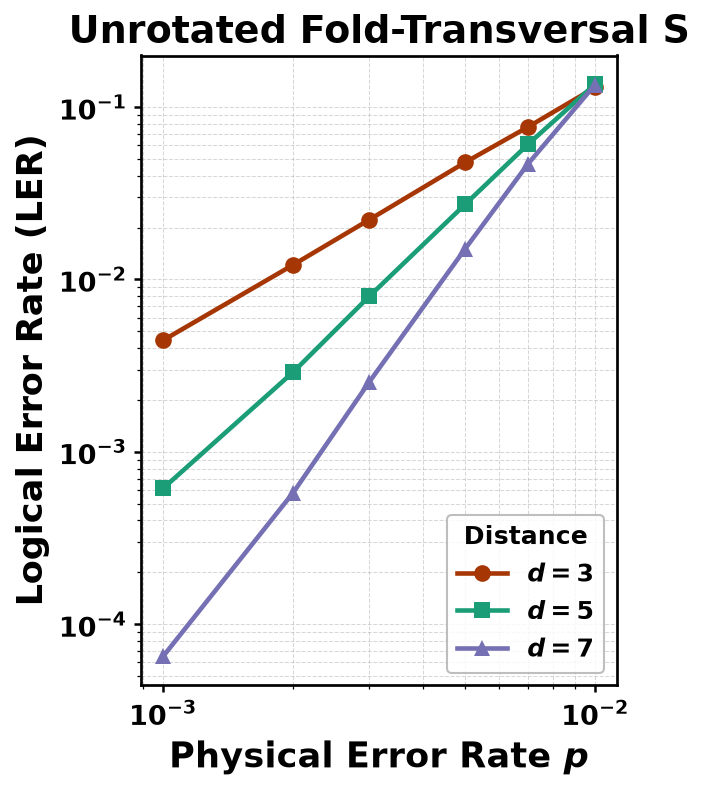

In [4]:
# ── LER vs Physical Error Rate — Phase (S) ────────────────────────────────────
from lightstim.protocols.fold_transversal import build_s_roundtrip_circuit

def ler_S(dd, noise):
    with contextlib.redirect_stdout(io.StringIO()):
        c = build_s_roundtrip_circuit(dd, rounds=rounds, noise_params=noise)
    return sweep_pipeline.run(c).logical_error_rate

ler_curves_S = {dd: [] for dd in DISTANCES}
print(f"{'d':>3} {'p':>9}   LER (S roundtrip)")
print("-" * 48)
for dd in DISTANCES:
    for pp in P_SWEEP:
        noise = NoiseConfig(p_idle=pp, p_1q=pp, p_2q=pp, p_meas=pp, p_reset=pp)
        v = ler_S(dd, noise)
        ler_curves_S[dd].append(v)
        print(f"{dd:>3} {pp:>9.0e}   {v:.3e}")

apply_paper_style()
fig, ax = plt.subplots(figsize=(4.5, 5.5))
proxies = []
for dd in DISTANCES:
    color  = PALETTE_DISTANCE.get(dd, "gray")
    marker = MARKERS.get(dd, "o")
    _y = np.array(ler_curves_S[dd], dtype=float)
    _y[_y <= 0] = np.nan  # drop zero-error points (e.g. d=7 low-p) from the log plot
    ax.loglog(P_SWEEP, _y, marker=marker, color=color,
              linestyle="-", markeredgecolor="none")
    proxies.append(mlines.Line2D([], [], color=color, ls="-", marker=marker,
                                 markersize=8, markeredgecolor="none", label=f"$d = {dd}$"))

ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel("Logical Error Rate (LER)")
ax.set_title("Unrotated Fold-Transversal S")
ax.grid(True, which="both", ls="--", linewidth=0.5, alpha=0.5)
bold_ticks(ax)
leg = ax.legend(handles=proxies, title="Distance", loc="lower right",
                frameon=True, framealpha=0.85)
leg.get_title().set_fontweight("bold")
fig.tight_layout()
fig.savefig("logical_S_unrotated_LER_vs_p.png", dpi=150, bbox_inches="tight")
plt.show()